In [1]:
from meta import *
import pandas as pd
import numpy as np

df = pd.read_csv(datapath+r"\climate_prep.csv", encoding="utf-8")

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420224 entries, 0 to 420223
Data columns (total 24 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   p (mbar)         420224 non-null  float64
 1   T (degC)         420224 non-null  float64
 2   Tpot (K)         420224 non-null  float64
 3   Tdew (degC)      420224 non-null  float64
 4   rh (%)           420224 non-null  float64
 5   VPmax (mbar)     420224 non-null  float64
 6   VPact (mbar)     420224 non-null  float64
 7   VPdef (mbar)     420224 non-null  float64
 8   sh (g/kg)        420224 non-null  float64
 9   H2OC (mmol/mol)  420224 non-null  float64
 10  rho (g/m**3)     420224 non-null  float64
 11  wv (m/s)         420224 non-null  float64
 12  max. wv (m/s)    420224 non-null  float64
 13  wd (deg)         420224 non-null  float64
 14  hour_sin         420224 non-null  float64
 15  hour_cos         420224 non-null  float64
 16  day_sin          420224 non-null  floa

In [3]:
from sklearn.model_selection import train_test_split

train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]

print(len(train_df), len(val_df), len(test_df))

294156 63033 63035


In [4]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

In [5]:
temp_idx = train_df.columns.get_loc("T (degC)")
hum_idx = train_df.columns.get_loc("rh (%)")

target_cols = [temp_idx, hum_idx]

In [6]:
import numpy as np

def create_sequences(data, window_size, target_cols):

    X = []
    y = []

    for i in range(len(data) - window_size):

        X.append(data[i:i+window_size])

        y.append(data[i+window_size, target_cols])

    return np.array(X), np.array(y)

In [7]:
WINDOW = 24

In [8]:
X_train, y_train = create_sequences(train_scaled, WINDOW, target_cols)

X_val, y_val = create_sequences(val_scaled, WINDOW, target_cols)

X_test, y_test = create_sequences(test_scaled, WINDOW, target_cols)

In [9]:
X_train = X_train.reshape(X_train.shape[0], -1)

X_val = X_val.reshape(X_val.shape[0], -1)

X_test = X_test.reshape(X_test.shape[0], -1)

In [10]:
print(X_train.shape)
print(y_train.shape)

(294132, 576)
(294132, 2)


In [12]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation="leaky_relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(128, activation="leaky_relu"),
    Dropout(0.3),

    Dense(64, activation="leaky_relu"),

    Dense(2)   # Temperature and Humidity
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,994 (738.26 KB)

 Trainable params: 188,994 (738.26 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/30
4596/4596 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - loss: 0.0041 - mae: 0.0404 - val_loss: 5.1138 - val_mae: 0.0670
Epoch 2/30
4596/4596 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step - loss: 9.6686e-04 - mae: 0.0235 - val_loss: 6.9116 - val_mae: 0.0649
Epoch 3/30
4596/4596 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - loss: 7.1897e-04 - mae: 0.0202 - val_loss: 1.3113 - val_mae: 0.0426
Epoch 4/30
4596/4596 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - loss: 6.0859e-04 - mae: 0.0185 - val_loss: 6.9574 - val_mae: 0.0772
Epoch 5/30
4596/4596 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - loss: 5.2237e-04 - mae: 0.0171 - val_loss: 1.8976 - val_mae: 0.0450
Epoch 6/30
4596/4596 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - loss: 4.8075e-04 - mae: 0.0164 - val_loss: 0.3755 - val_mae: 0.0303
Epoch 7/30
4596/4596 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - loss: 4.3889e-04 - mae: 0.0156 - val_loss: 2.6493 - val_mae: 0.0502
Epoch 8/30
4596/4596 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - loss: 4.1697e-04 - mae: 0.0152 - val_loss: 1.3091 - val_mae: 0.0440
Epoc

In [14]:
test_loss, test_mae = model.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test MAE : {test_mae:.4f}")

1970/1970 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 6.7191e-04 - mae: 0.0170
Test Loss: 0.0007
Test MAE : 0.0170


In [17]:
y_pred = model.predict(X_test)

1970/1970 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


MODEL PERFORMANCE

Temperature
MAE  : 0.722 °C
RMSE : 0.927 °C
R²   : 0.9858

Humidity
MAE  : 1.890 %
RMSE : 2.881 %
R²   : 0.9657


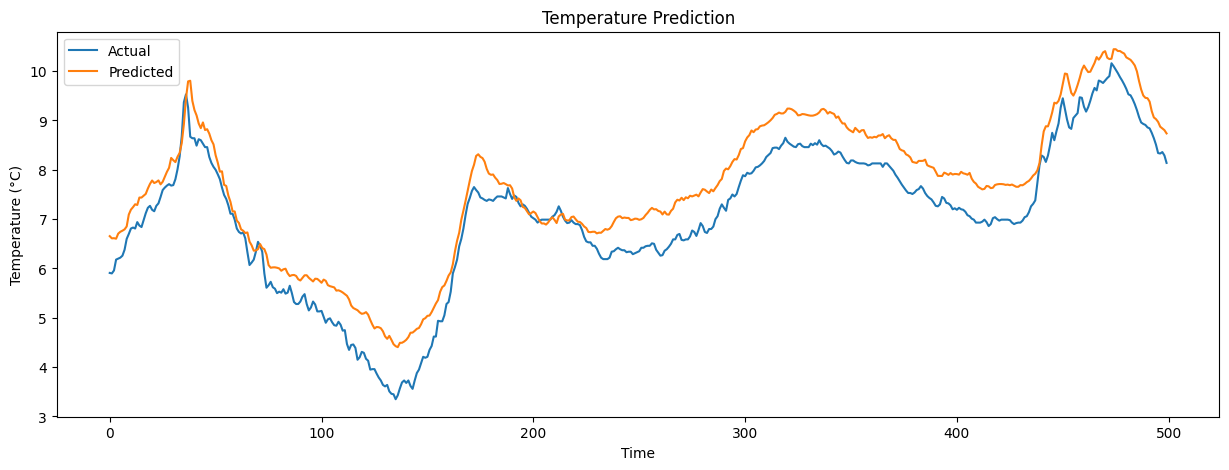

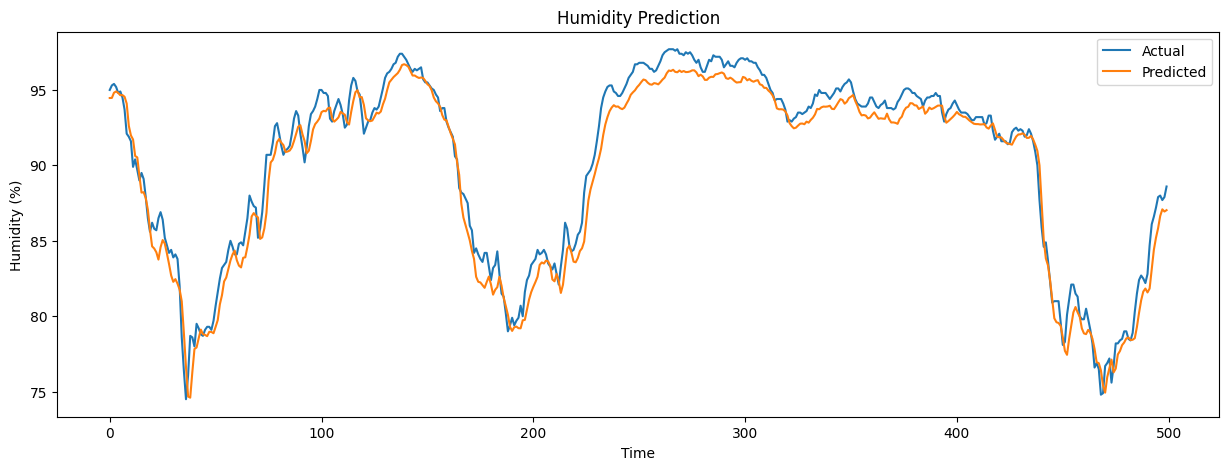

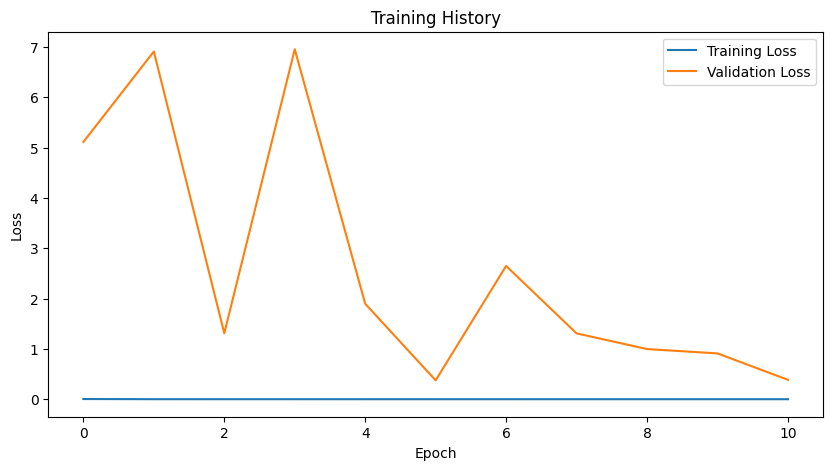

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ================================
# Inverse Transform Predictions
# ================================

temp_idx = train_df.columns.get_loc("T (degC)")
hum_idx = train_df.columns.get_loc("rh (%)")

n_features = train_df.shape[1]

dummy_true = np.zeros((len(y_test), n_features))
dummy_pred = np.zeros((len(y_pred), n_features))

dummy_true[:, temp_idx] = y_test[:, 0]
dummy_true[:, hum_idx] = y_test[:, 1]

dummy_pred[:, temp_idx] = y_pred[:, 0]
dummy_pred[:, hum_idx] = y_pred[:, 1]

true_inverse = scaler.inverse_transform(dummy_true)
pred_inverse = scaler.inverse_transform(dummy_pred)

true_temp = true_inverse[:, temp_idx]
true_hum = true_inverse[:, hum_idx]

pred_temp = pred_inverse[:, temp_idx]
pred_hum = pred_inverse[:, hum_idx]

# ================================
# Metrics
# ================================

temp_mae = mean_absolute_error(true_temp, pred_temp)
temp_rmse = np.sqrt(mean_squared_error(true_temp, pred_temp))
temp_r2 = r2_score(true_temp, pred_temp)

hum_mae = mean_absolute_error(true_hum, pred_hum)
hum_rmse = np.sqrt(mean_squared_error(true_hum, pred_hum))
hum_r2 = r2_score(true_hum, pred_hum)

print("=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)

print("\nTemperature")
print(f"MAE  : {temp_mae:.3f} °C")
print(f"RMSE : {temp_rmse:.3f} °C")
print(f"R²   : {temp_r2:.4f}")

print("\nHumidity")
print(f"MAE  : {hum_mae:.3f} %")
print(f"RMSE : {hum_rmse:.3f} %")
print(f"R²   : {hum_r2:.4f}")

# ================================
# Temperature Plot
# ================================

plt.figure(figsize=(15,5))

plt.plot(true_temp[:500], label="Actual")
plt.plot(pred_temp[:500], label="Predicted")

plt.title("Temperature Prediction")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()

plt.show()

# ================================
# Humidity Plot
# ================================

plt.figure(figsize=(15,5))

plt.plot(true_hum[:500], label="Actual")
plt.plot(pred_hum[:500], label="Predicted")

plt.title("Humidity Prediction")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()

plt.show()

# ================================
# Training Curve
# ================================

plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()